# Анализ данных по компенсациям в IT-сфере

Данный набор заданий позволит последовательно освоить:
- базовые агрегатные операции;
- группировки с агрегацией;
- фильтрацию данных;
- исследовательский анализ (EDA);
- построение визуализаций и выводы.

Все задания выполняются на датасете, содержащем записи о заработных платах, бонусах, акциях, опыте, уровне образования и других характеристиках сотрудников.

# Описание полей

- `timestamp` -- дата и время поста 
<br>
- `company` -- название компании
<br>
- `level` -- уровень специалиста (jun - mid - senior etc)
<br>
- `title` -- название вакансии 
<br>
- `totalyearlycompensation` -- годовая заработная плана. в контексте всех последующих задач, именно это поле будет иметься в виду под названием "зарплата"
<br>
- `location` -- город и штат\страна, где работает специалист
<br>
- `yearsofexperience` -- уровень специалиста
<br>
- `yearsatcompany` -- опыт работы специалиста 
<br>
- `basesalary` -- базовая компенсация
<br>



In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('P01_Salaries_Dataset.csv')

In [ ]:
df.head()

In [ ]:
df.shape

# Задания

## 1. Топ-10 компаний по суммарной компенсации
**Задание:**  
Определите 10 компаний, суммарно выплачивающих наибольшую **totalyearlycompensation**

**Требования:**  
- Посчитайте общее значение компенсаций для каждой компании
- Выведите топ-10 компаний и их суммарные выплаты

Первые 5 строк датасета:
            timestamp    company level                         title  \
0   6/7/2017 11:33:27     Oracle    L3               Product Manager   
1  6/10/2017 17:11:29       eBay  SE 2             Software Engineer   
2  6/11/2017 14:53:57     Amazon    L7               Product Manager   
3   6/17/2017 0:23:14      Apple    M1  Software Engineering Manager   
4  6/20/2017 10:58:51  Microsoft    60             Software Engineer   

   totalyearlycompensation           location  yearsofexperience  \
0                   127000   Redwood City, CA                1.5   
1                   100000  San Francisco, CA                5.0   
2                   310000        Seattle, WA                8.0   
3                   372000      Sunnyvale, CA                7.0   
4                   157000  Mountain View, CA                5.0   

   yearsatcompany  tag  basesalary  stockgrantvalue    bonus gender Race  \
0             1.5  NaN    107000.0          20000.0  1000

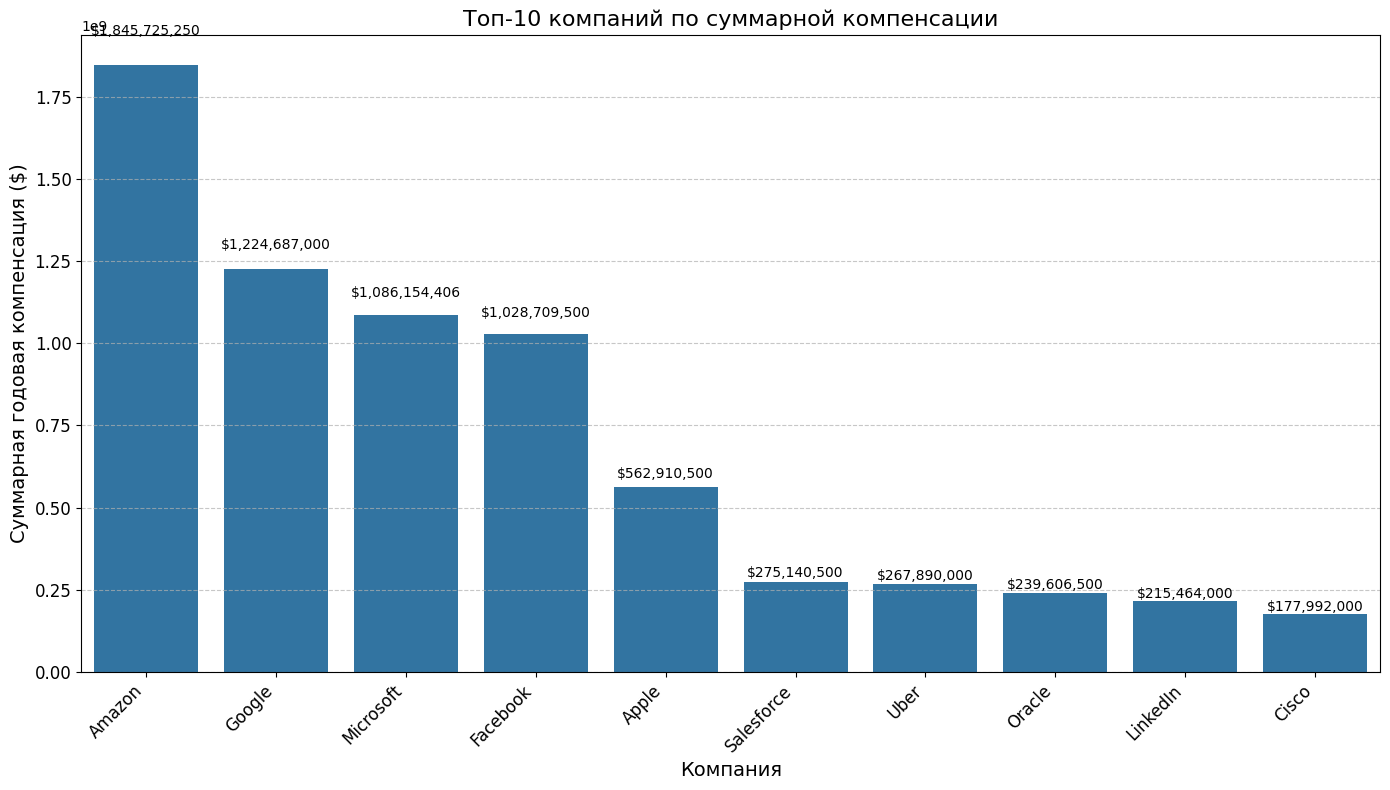


Статистика по топ-10 компаниям:
Общая сумма выплат: $6,924,279,656
Средняя компенсация на компанию: $692,427,966
Максимальная компенсация: $1,845,725,250 (Amazon)
Минимальная компенсация в топ-10: $177,992,000 (Cisco)

Топ-10 компаний составляют 51.14% от общей суммы компенсаций


In [5]:
import pandas as pd

file_path = "C:\\Users\\user\\P01_Salaries_Dataset.csv" 
df = pd.read_csv(file_path)

print("Первые 5 строк датасета:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nКоличество пропущенных значений в столбце totalyearlycompensation:")
print(df['totalyearlycompensation'].isna().sum())

if df['totalyearlycompensation'].dtype == 'object':
    df['totalyearlycompensation'] = pd.to_numeric(df['totalyearlycompensation'], errors='coerce')
    print("\nПреобразованы строковые значения в числовые для столбца totalyearlycompensation")
    
if df['totalyearlycompensation'].isna().sum() > 0:
    df = df.dropna(subset=['totalyearlycompensation'])
    print(f"\nУдалены строки с пропущенными значениями в столбце totalyearlycompensation")

if df['company'].isna().sum() > 0:
    df = df.dropna(subset=['company'])
    print(f"\nУдалены строки с пропущенными значениями в столбце company")
    
print(f"\nПосле обработки в датасете осталось {len(df)} строк")

company_compensation = df.groupby('company')['totalyearlycompensation'].sum().reset_index()

print("\nРезультат группировки (первые 5 строк):")
print(company_compensation.head())

print(f"\nКоличество уникальных компаний: {len(company_compensation)}")

company_compensation_sorted = company_compensation.sort_values(by='totalyearlycompensation', ascending=False)

top10 = company_compensation_sorted.head(10)

print("\nТоп-10 компаний по суммарной компенсации:")
print(top10)

top10_display = top10.copy()
top10_display['totalyearlycompensation'] = top10_display['totalyearlycompensation'].apply(lambda x: f"${x:,.0f}")

print("\nТоп-10 компаний по суммарной компенсации (форматированный вывод):")
print(top10_display)

plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(x='company', y='totalyearlycompensation', data=top10)
plt.title('Топ-10 компаний по суммарной компенсации', fontsize=16)
plt.xlabel('Компания', fontsize=14)
plt.ylabel('Суммарная годовая компенсация ($)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

for i, v in enumerate(top10['totalyearlycompensation']):
    bar_plot.text(i, v + 0.05*v, f"${v:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nСтатистика по топ-10 компаниям:")
print(f"Общая сумма выплат: ${top10['totalyearlycompensation'].sum():,.0f}")
print(f"Средняя компенсация на компанию: ${top10['totalyearlycompensation'].mean():,.0f}")
print(f"Максимальная компенсация: ${top10['totalyearlycompensation'].max():,.0f} ({top10.iloc[0]['company']})")
print(f"Минимальная компенсация в топ-10: ${top10['totalyearlycompensation'].min():,.0f} ({top10.iloc[9]['company']})")

total_all_companies = company_compensation['totalyearlycompensation'].sum()
total_top10 = top10['totalyearlycompensation'].sum()
percent_top10 = (total_top10 / total_all_companies) * 100

print(f"\nТоп-10 компаний составляют {percent_top10:.2f}% от общей суммы компенсаций")

## 2. Средний опыт работы для Software Engineers в Oracle
**Задание:**  
Для сотрудников с должностью `Software Engineer` в компании `Oracle` найдите средний опыт работы (**yearsofexperience**), при условии, что их заработная плата превышает 50 000

**Требования:**  
- Фильтрация по компании, должности и пороговому значению зарплаты
- Вычисление среднего значения опыта

In [6]:
filtered_df = df[(df['company'] == 'Oracle') & (df['title'] == 'Software Engineer') & (df['totalyearlycompensation'] > 50000)]
average_experience = filtered_df['yearsofexperience'].mean()
print(average_experience)

7.872159090909091


## 3. Средние зарплаты по заданным локациям
**Задание:**  
Рассчитайте среднюю **totalyearlycompensation** для локаций:  
- Austin, TX  
- London, EN, United Kingdom  
- Redmond, WA

**Требования:**  
- Обратите внимание на возможное различие в формате записи локаций

In [7]:
locations_to_analyze = ['Austin, TX', 'London, EN, United Kingdom', 'Redmond, WA']
average_compensation_by_location = {}

for location in locations_to_analyze:
    location_df = df[df['location'] == location]

    if not location_df.empty:
        average_compensation = location_df['totalyearlycompensation'].mean()
        average_compensation_by_location[location] = average_compensation
    else:
        average_compensation_by_location[location] = "Нет данных"

for location, avg_comp in average_compensation_by_location.items():
    print(f"Средняя годовая компенсация в {location}: {avg_comp}")

Средняя годовая компенсация в Austin, TX: 179489.18032786885
Средняя годовая компенсация в London, EN, United Kingdom: 170305.6640625
Средняя годовая компенсация в Redmond, WA: 224927.78617302608


## 4. Сравнение заработных плат между FAANG и остальными компаниями для Software Engineers
**Задание:**  
Разделите записи по двум группам:  
- Компании из списка FAANG (Facebook, Apple, Amazon, Netflix, Google)
- Остальные компании

Для сотрудников с должностью `Software Engineer` сравните средние значения **totalyearlycompensation** между группами

In [8]:
faang_companies = ['Facebook', 'Apple', 'Amazon', 'Netflix', 'Google']

software_engineers_df = df[df['title'] == 'Software Engineer'].copy()

software_engineers_df['is_faang'] = software_engineers_df['company'].apply(lambda company: company in faang_companies)

average_salary_comparison = software_engineers_df.groupby('is_faang')['totalyearlycompensation'].mean()

average_salary_comparison.index = ['Остальные компании', 'FAANG компании']

print("Средняя годовая компенсация для Software Engineers:")
print(average_salary_comparison)

Средняя годовая компенсация для Software Engineers:
Остальные компании    186121.738530
FAANG компании        255960.225775
Name: totalyearlycompensation, dtype: float64


## 5. Влияние уровня образования на заработную плату
**Задание:**  
Исследуйте, как наличие или отсутствие данных об образовании влияет на **totalyearlycompensation**

**Требования:**  
- Сравните среднюю компенсацию для групп: с указанным уровнем образования и без него
- Прокомментируйте возможные выводы

In [9]:
df['has_education_info'] = df['Education'].notna()

average_salary_by_education = df.groupby('has_education_info')['totalyearlycompensation'].mean()

average_salary_by_education.index = ['Нет информации об образовании', 'Информация об образовании указана']

print("Средняя годовая компенсация в зависимости от наличия информации об образовании:")
print(average_salary_by_education)

Средняя годовая компенсация в зависимости от наличия информации об образовании:
Нет информации об образовании        225573.396817
Информация об образовании указана    206452.048478
Name: totalyearlycompensation, dtype: float64


## 6. Взаимосвязь между опытом работы и заработной платой
**Задание:**  
Оцените зависимость между **yearsofexperience** и **totalyearlycompensation**

**Требования:**  
- Постройте scatter plot (точечную диаграмму) для визуализации связи
- Рассчитайте коэффициент корреляции и прокомментируйте результат

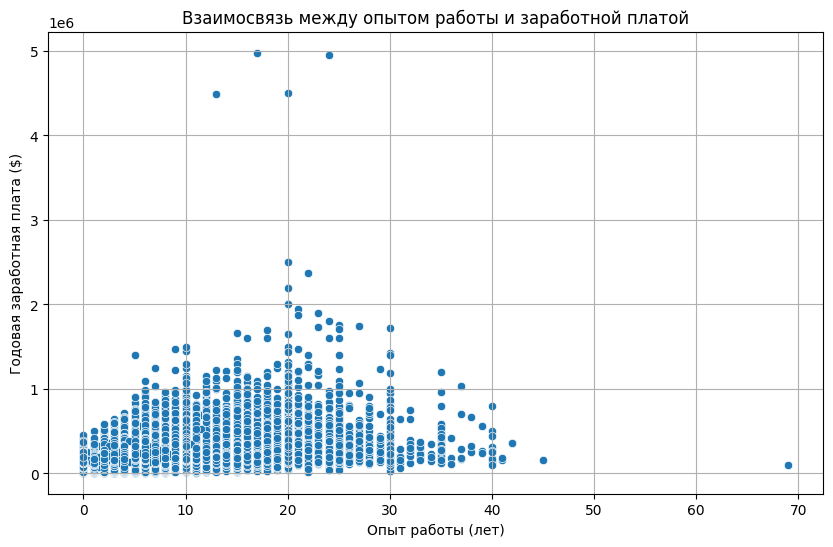


Коэффициент корреляции Пирсона между опытом работы и заработной платой: 0.42

Комментарий:
Наблюдается умеренная положительная корреляция. С увеличением опыта работы заработная плата имеет тенденцию к росту, но эта связь не является строго линейной.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='yearsofexperience', y='totalyearlycompensation', data=df)
plt.title('Взаимосвязь между опытом работы и заработной платой')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Годовая заработная плата ($)')
plt.grid(True)
plt.show()

correlation = df['yearsofexperience'].corr(df['totalyearlycompensation'])
print(f"\nКоэффициент корреляции Пирсона между опытом работы и заработной платой: {correlation:.2f}")

print("\nКомментарий:")
if correlation > 0.7:
    print("Наблюдается сильная положительная корреляция. С увеличением опыта работы, как правило, значительно возрастает и заработная плата.")
elif 0.3 < correlation <= 0.7:
    print("Наблюдается умеренная положительная корреляция. С увеличением опыта работы заработная плата имеет тенденцию к росту, но эта связь не является строго линейной.")
elif -0.3 <= correlation <= 0.3:
    print("Наблюдается слабая корреляция или ее отсутствие. Опыт работы слабо связан с уровнем заработной платы.")
elif -0.7 <= correlation < -0.3:
    print("Наблюдается умеренная отрицательная корреляция. С увеличением опыта работы заработная плата имеет тенденцию к снижению (что маловероятно в данном контексте).")
else: # correlation < -0.7
    print("Наблюдается сильная отрицательная корреляция. С увеличением опыта работы заработная плата значительно снижается (что крайне маловероятно в данном контексте).")

## 7. Анализ зарплат по грейдам в компании Amazon для Software Engineers
**Задание:**  
Для компании `Amazon` изучите, как различаются зарплаты на позиции `Software Engineer` в зависимости от грейда (**level**)

**Требования:**  
- Сгруппируйте данные по грейдам
- Рассчитайте средние значения и визуализируйте результаты
- Сравните с исследованиями, приведёнными по ссылкам
  - [Career Karma](https://careerkarma.com/blog/software-engineering-salary-amazon/)
  - [Исследование зарплат в Казахстане](https://zerttey.kolesa.group/datascience#zp)

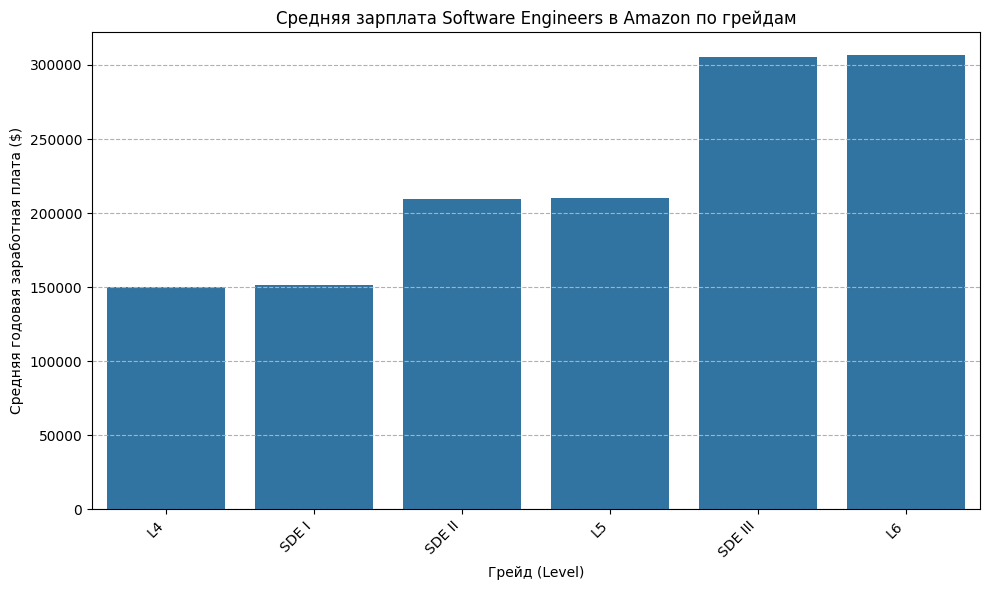


Средняя зарплата Software Engineers в Amazon по грейдам:
level
L4         150296.652422
SDE I      151629.206731
SDE II     209411.616162
L5         209929.092805
SDE III    305133.333333
L6         306690.196078
Name: totalyearlycompensation, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

amazon_se_df = df[(df['company'] == 'Amazon') & (df['title'] == 'Software Engineer')].copy()

average_salary_by_level = amazon_se_df.groupby('level')['totalyearlycompensation'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=average_salary_by_level.index, y=average_salary_by_level.values)
plt.title('Средняя зарплата Software Engineers в Amazon по грейдам')
plt.xlabel('Грейд (Level)')
plt.ylabel('Средняя годовая заработная плата ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

print("\nСредняя зарплата Software Engineers в Amazon по грейдам:")
print(average_salary_by_level)

## 8. Влияние местоположения на компенсацию для одинаковых позиций
**Задание:**  
Проведите анализ разницы в **totalyearlycompensation** для одинаковых должностей (например, `Software Engineer`) в различных локациях

**Требования:**  
- Сравните компенсации для выбранной должности в разных регионах.
- Выведите выводы о региональных различиях

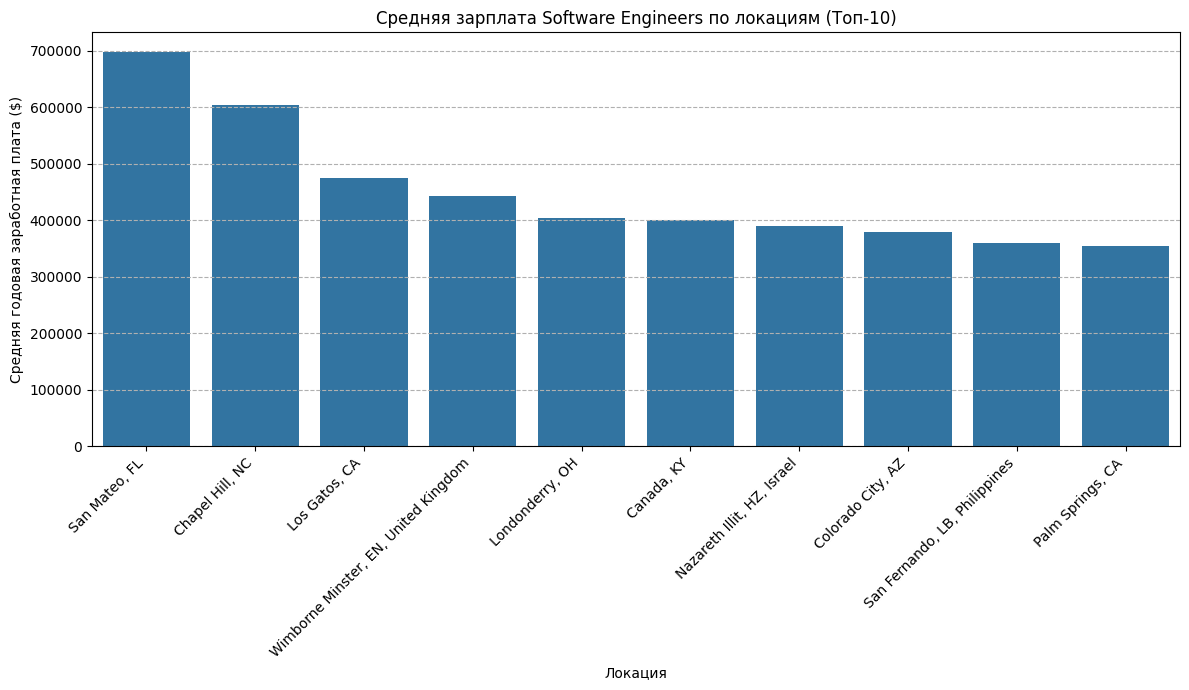


Средняя зарплата Software Engineers по топ-10 локациям:
location
San Mateo, FL                           698000.00000
Chapel Hill, NC                         605000.00000
Los Gatos, CA                           474994.08284
Wimborne Minster, EN, United Kingdom    444000.00000
Londonderry, OH                         405000.00000
Canada, KY                              400000.00000
Nazareth Illit, HZ, Israel              390000.00000
Colorado City, AZ                       380000.00000
San Fernando, LB, Philippines           360000.00000
Palm Springs, CA                        355000.00000
Name: totalyearlycompensation, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

software_engineers_df = df[df['title'] == 'Software Engineer'].copy()

average_salary_by_location = software_engineers_df.groupby('location')['totalyearlycompensation'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=average_salary_by_location.index, y=average_salary_by_location.values)
plt.title('Средняя зарплата Software Engineers по локациям (Топ-10)')
plt.xlabel('Локация')
plt.ylabel('Средняя годовая заработная плата ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

print("\nСредняя зарплата Software Engineers по топ-10 локациям:")
print(average_salary_by_location)

## 9. Анализ гендерного и расового равенства в зарплатах
**Задание:**  
Проведите сравнительный анализ заработных плат между мужчинами и женщинами, а также постройте распределение **totalyearlycompensation** по расовым группам

**Требования:**  
- Вычислите средние зарплаты для каждой группы.
- Постройте соответствующие графики (boxplot, violin plot, histogram).

Средняя годовая компенсация по гендерным группам:
gender
Female                             195021.303975
Male                               212449.960922
Other                              232288.944724
Title: Senior Software Engineer    205000.000000
Name: totalyearlycompensation, dtype: float64


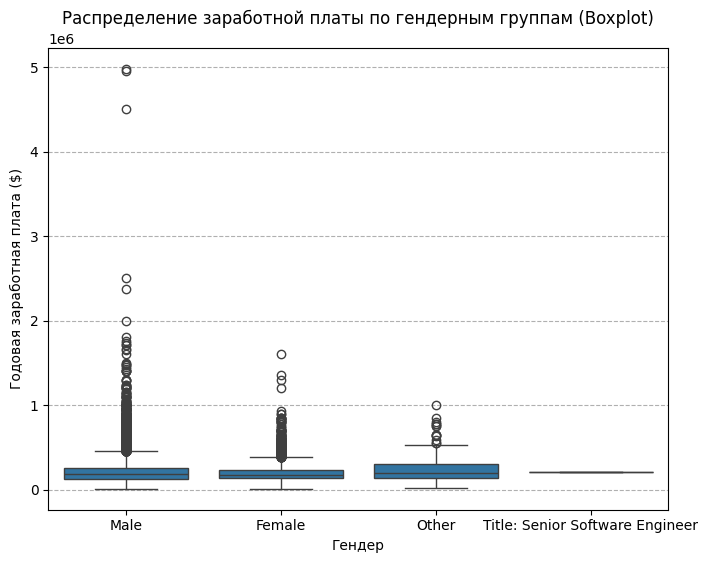

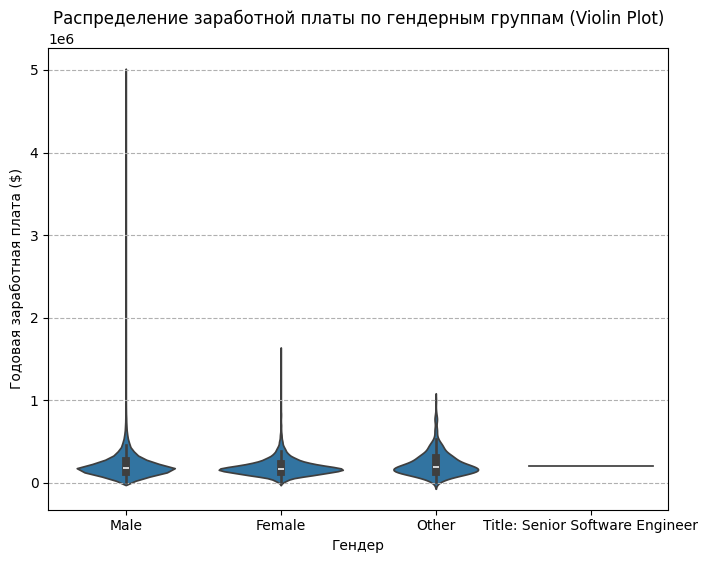

C:\Users\user\AppData\Local\Temp\ipykernel_19268\1272172828.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Гендер')


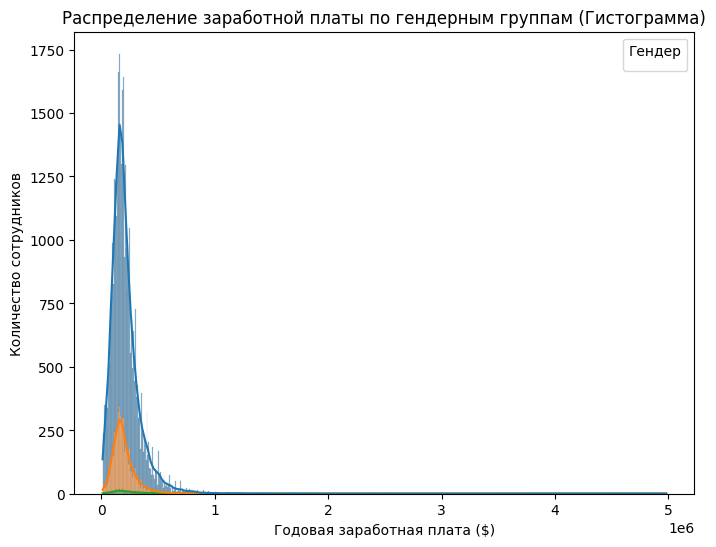

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

average_salary_by_gender = df.groupby('gender')['totalyearlycompensation'].mean()
print("Средняя годовая компенсация по гендерным группам:")
print(average_salary_by_gender)

plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='totalyearlycompensation', data=df)
plt.title('Распределение заработной платы по гендерным группам (Boxplot)')
plt.xlabel('Гендер')
plt.ylabel('Годовая заработная плата ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='gender', y='totalyearlycompensation', data=df)
plt.title('Распределение заработной платы по гендерным группам (Violin Plot)')
plt.xlabel('Гендер')
plt.ylabel('Годовая заработная плата ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='totalyearlycompensation', hue='gender', kde=True, multiple='stack')
plt.title('Распределение заработной платы по гендерным группам (Гистограмма)')
plt.xlabel('Годовая заработная плата ($)')
plt.ylabel('Количество сотрудников')
plt.legend(title='Гендер')
plt.show()

[nan 'White' 'Asian' 'Black' 'Two Or More' 'Hispanic']
Race
White          206305.316897
Two Or More    204651.741294
Asian          193324.753653
Hispanic       189821.808511
Black          181324.637681
Name: totalyearlycompensation, dtype: float64


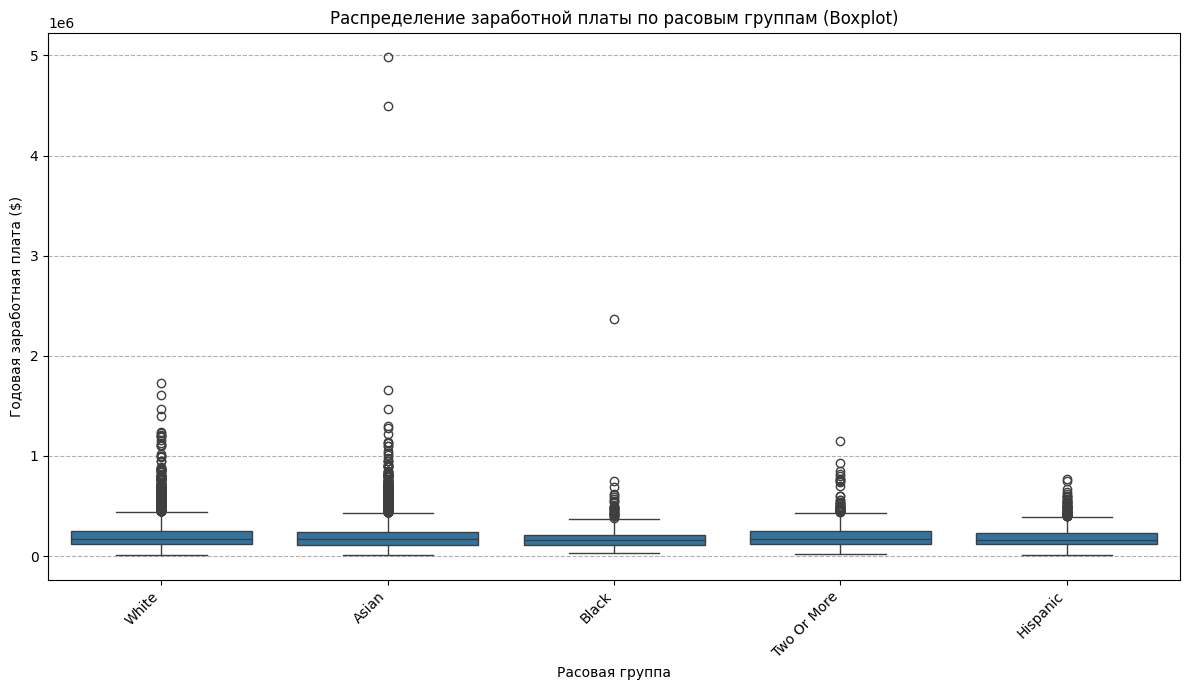

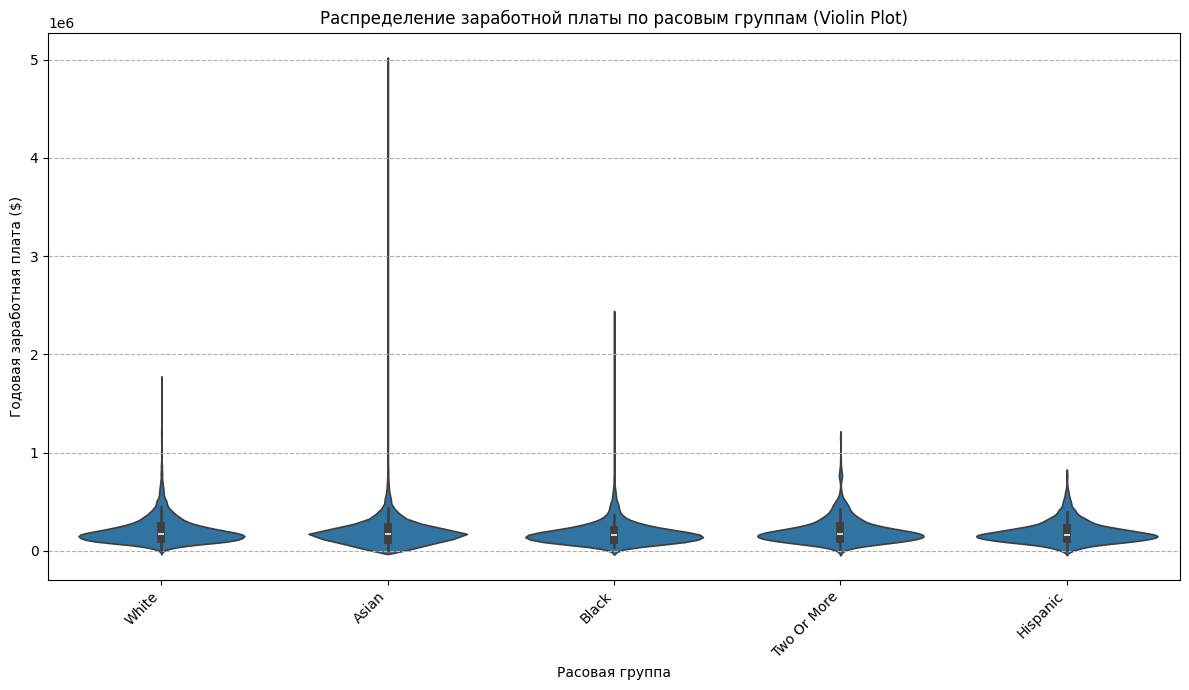

C:\Users\user\AppData\Local\Temp\ipykernel_19268\440299792.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Расовая группа')


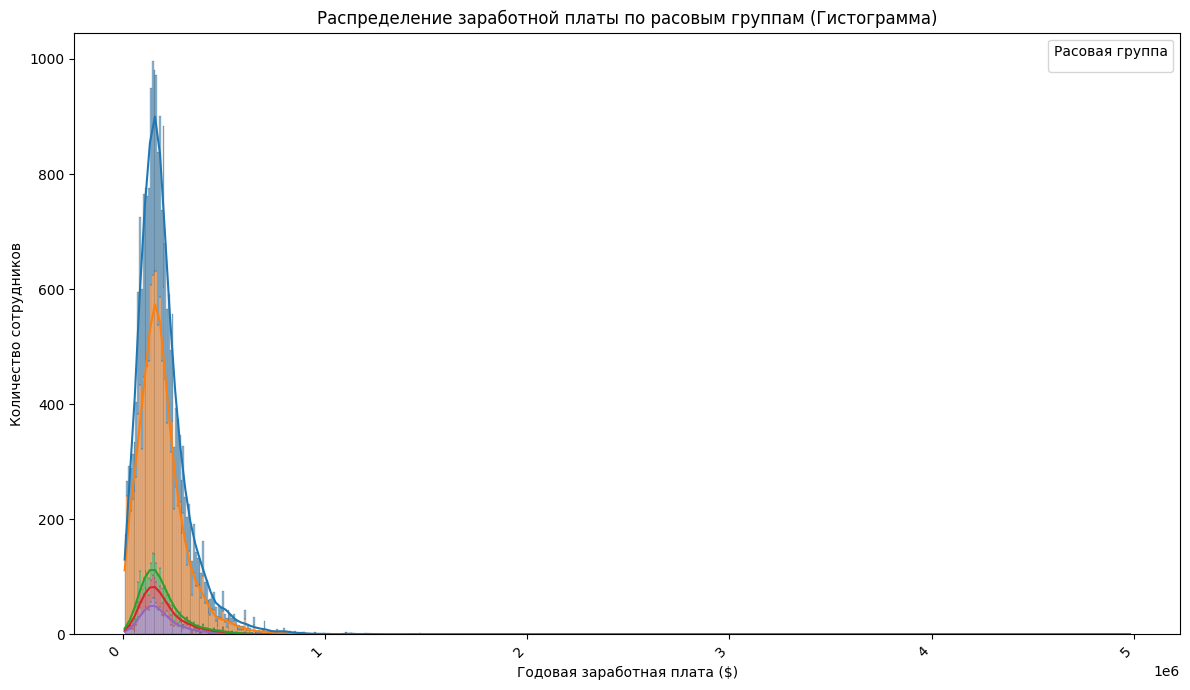

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


print(df['Race'].unique())

average_salary_by_race = df.groupby('Race')['totalyearlycompensation'].mean().sort_values(ascending=False)
print(average_salary_by_race)

plt.figure(figsize=(12, 7))
sns.boxplot(x='Race', y='totalyearlycompensation', data=df)
plt.title('Распределение заработной платы по расовым группам (Boxplot)')
plt.xlabel('Расовая группа')
plt.ylabel('Годовая заработная плата ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

plt.figure(figsize=(12, 7))
sns.violinplot(x='Race', y='totalyearlycompensation', data=df)
plt.title('Распределение заработной платы по расовым группам (Violin Plot)')
plt.xlabel('Расовая группа')
plt.ylabel('Годовая заработная плата ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='totalyearlycompensation', hue='Race', kde=True, multiple='stack')
plt.title('Распределение заработной платы по расовым группам (Гистограмма)')
plt.xlabel('Годовая заработная плата ($)')
plt.ylabel('Количество сотрудников')
plt.legend(title='Расовая группа')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. «Переплата» за опыт
**Задание:**  
Для сотрудников с должностью `Software Engineer` рассчитайте среднюю стоимость одного года опыта как отношение **totalyearlycompensation / yearsofexperience** для каждой компании

**Требования:**  
- Определите компании, где за один год опыта платят больше всего, и, наоборот, где меньше
- Проанализируйте, насколько подобный показатель отличается между компаниями

In [16]:
import pandas as pd

software_engineers_df = df[df['title'] == 'Software Engineer'].copy()

software_engineers_df = software_engineers_df[software_engineers_df['yearsofexperience'] > 0]

software_engineers_df['compensation_per_year_of_experience'] = software_engineers_df['totalyearlycompensation'] / software_engineers_df['yearsofexperience']

average_compensation_per_year_by_company = software_engineers_df.groupby('company')['compensation_per_year_of_experience'].mean().sort_values(ascending=False)

print("Топ-10 компаний с самой высокой средней 'переплатой' за год опыта (для Software Engineers):")
print(average_compensation_per_year_by_company.head(10))

print("\nТоп-10 компаний с самой низкой средней 'переплатой' за год опыта (для Software Engineers):")
print(average_compensation_per_year_by_company.tail(10))

print(f"\nМаксимальная средняя 'переплата' за год опыта: ${average_compensation_per_year_by_company.max():,.2f}")
print(f"Минимальная средняя 'переплата' за год опыта: ${average_compensation_per_year_by_company.min():,.2f}")
print(f"Средняя 'переплата' за год опыта по всем компаниям: ${average_compensation_per_year_by_company.mean():,.2f}")
print(f"Стандартное отклонение 'переплаты' за год опыта: ${average_compensation_per_year_by_company.std():,.2f}")

Топ-10 компаний с самой высокой средней 'переплатой' за год опыта (для Software Engineers):
company
PDT Partners            253333.333333
Five Rings              210833.333333
Virtu financial         205000.000000
Jump Trading            190000.000000
Jane Street Capital     175535.714286
EBAY                    175000.000000
snapchat                161666.666667
Optiver                 160687.500000
Jane Street             159458.333333
Cornerstone Ondemand    152000.000000
Name: compensation_per_year_of_experience, dtype: float64

Топ-10 компаний с самой низкой средней 'переплатой' за год опыта (для Software Engineers):
company
Zoho             4381.060606
Mcafee           4285.714286
discover         3833.333333
Mail.Ru Group    3400.000000
AthenaHealth     2875.000000
HERE             2857.142857
BNP Paribas      2385.714286
siemens          2250.000000
HP inc           2250.000000
Mercer           1833.333333
Name: compensation_per_year_of_experience, dtype: float64

Максимальная 

## 11. Сравнение компенсаций внутри FAANG по различным позициям
**Задание:**  
Для компаний из списка FAANG (Facebook, Apple, Amazon, Netflix, Google) сравните средние значения **totalyearlycompensation** по трём позициям:  
- Software Engineer  
- Product Manager  
- Data Scientist  

**Требования:**  
- Рассчитайте не только общую компенсацию, но и соотношение бонусов и акций
- Сформулируйте выводы, где какая позиция оплачивается лучше и чем обусловлено различие

In [17]:
import pandas as pd

faang_companies = ['Facebook', 'Apple', 'Amazon', 'Netflix', 'Google']

target_titles = ['Software Engineer', 'Product Manager', 'Data Scientist']

faang_df = df[(df['company'].isin(faang_companies)) & (df['title'].isin(target_titles))].copy()

average_compensation_faang = faang_df.groupby('title')['totalyearlycompensation'].mean().sort_values(ascending=False)

print("Средняя годовая компенсация по позициям внутри FAANG:")
print(average_compensation_faang)

Средняя годовая компенсация по позициям внутри FAANG:
title
Product Manager      318381.379310
Data Scientist       258268.867925
Software Engineer    255960.225775
Name: totalyearlycompensation, dtype: float64


## 12. Группировка и агрегация: компенсации по грейду и должности
**Задание:**  
Для каждой уникальной комбинации **level** и **title** рассчитайте:
- Среднее (mean) **totalyearlycompensation**
- Минимальное (min) и максимальное (max) **totalyearlycompensation**  
Отсортируйте результат по убыванию среднего значения

**Требования:**  
- Используйте метод `groupby().agg()`.
- Проанализируйте, какие грейды и должности лидируют по компенсации.

In [18]:
compensation_by_level_title = df.groupby(['level', 'title'])['totalyearlycompensation'].agg(['mean', 'min', 'max']).sort_values(by='mean', ascending=False)

print("Агрегированные компенсации по грейду и должности:")
print(compensation_by_level_title)

Агрегированные компенсации по грейду и должности:
                                                    mean      min      max
level            title                                                    
E9               Product Manager               4980000.0  4980000  4980000
80               Software Engineering Manager  2610000.0   270000  4950000
EVP              Software Engineering Manager  2000000.0  2000000  2000000
Sr Director      Product Manager               1900000.0  1900000  1900000
69               Software Engineering Manager  1750000.0  1750000  1750000
...                                                  ...      ...      ...
40               Software Engineer               10000.0    10000    10000
Fresher          Software Engineer               10000.0    10000    10000
Designer I       Product Designer                10000.0    10000    10000
Junior developer Software Engineer               10000.0    10000    10000
trainee          Mechanical Engineer             1